# Customer Churn - Model Validation

This notebook focuses on robust model validation for churn prediction.

The goal is not only to compare models, but to validate them in a disciplined way and assess whether their output is useful for business decision-making.

The workflow follows five principles:

1. reserve a holdout test set from the beginning,
2. compare candidate models using cross-validation on the training data,
3. report both average performance and variability across folds,
4. select the probability version using training data only,
5. evaluate the final selected probability model on the untouched holdout set.

This notebook answers two main questions:

- Which model generalizes best?
- Are the predicted probabilities reliable enough for thresholding and targeting?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    make_scorer,
    brier_score_loss
)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

## Data loading and reusable cleaning

This notebook is fully independent from the earlier notebooks.

The data is loaded and minimally cleaned again here using the same logic as before:
- strip whitespace from object columns,
- convert `TotalCharges` to numeric,
- drop rows where `TotalCharges` cannot be parsed.

This keeps the modeling notebook reproducible and self-contained.

In [2]:
# Load raw data
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

# Minimal reusable cleaning
object_cols = df.select_dtypes(include="object").columns

df_model = df.copy()

for col in object_cols:
    df_model[col] = df_model[col].astype(str).str.strip()

df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")
df_model = df_model.dropna(subset=["TotalCharges"]).copy()

print("Modeling dataset shape:", df_model.shape)
df_model.head()

Modeling dataset shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Base feature matrix and target
X_base = df_model.drop(columns=["customerID", "Churn"])
y = (df_model["Churn"] == "Yes").astype(int)

print("Base feature shape:", X_base.shape)
print("Churn rate:", round(y.mean(), 4))

Base feature shape: (7032, 19)
Churn rate: 0.2658


## First feature-engineering layer

The EDA suggested a few strong churn signals:
- month-to-month customers are riskier,
- new customers churn more,
- electronic check customers churn more,
- fiber optic customers churn more,
- service engagement may matter.

We encode a small, interpretable first layer of engineered features based on those patterns.

In [4]:
X = X_base.copy()

# Contract commitment
X["is_month_to_month"] = (X["Contract"] == "Month-to-month").astype(int)

# Early lifecycle
X["is_new_customer"] = (X["tenure"] <= 12).astype(int)

# Payment behavior
X["uses_electronic_check"] = (X["PaymentMethod"] == "Electronic check").astype(int)

# Internet service signal
X["has_fiber_optic"] = (X["InternetService"] == "Fiber optic").astype(int)

# Service engagement
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

def is_active_service(x):
    return int(str(x).strip() == "Yes")

X["service_count"] = X[service_cols].map(is_active_service).sum(axis=1)

# Simple interaction-style feature
X["fiber_month_to_month"] = X["has_fiber_optic"] * X["is_month_to_month"]

print("Feature shape after engineering:", X.shape)
X.head()

Feature shape after engineering: (7032, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,is_month_to_month,is_new_customer,uses_electronic_check,has_fiber_optic,service_count,fiber_month_to_month
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,1,1,1,0,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,0,0,0,0,3,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,1,1,0,0,3,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,0,0,0,0,3,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,1,1,1,1,1,1


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4))
print("Test churn rate :", round(y_test.mean(), 4))

Train shape: (5625, 25)
Test shape : (1407, 25)
Train churn rate: 0.2658
Test churn rate : 0.2658


In [6]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'is_month_to_month', 'is_new_customer', 'uses_electronic_check', 'has_fiber_optic', 'service_count', 'fiber_month_to_month']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Cross-validation strategy

Model comparison is performed with repeated stratified cross-validation on the training set.

This provides:
- multiple train/validation splits,
- preservation of class balance,
- and a distribution of scores rather than a single point estimate.

That distribution helps measure uncertainty in model fitness.

In [9]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [10]:
# Shared preprocessing for linear models
numeric_transformer_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer([
    ("num", numeric_transformer_lr, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Preprocessing for tree models
numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_transformer_tree, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

models = {
    "Dummy": Pipeline([
        ("preprocessor", preprocessor_lr),
        ("classifier", DummyClassifier(strategy="most_frequent"))
    ]),
    
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_lr),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            class_weight="balanced"
        ))
    ])
}

In [11]:
metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

cv_rows = []
fold_rows = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    n_runs = len(scores["test_roc_auc"])
    row = {"Model": model_name, "n_folds": n_runs}
    
    for metric in metric_names:
        values = scores[f"test_{metric}"]
        mean_val = np.mean(values)
        std_val = np.std(values, ddof=1)
        
        row[f"{metric}_mean"] = mean_val
        row[f"{metric}_std"] = std_val
        
        for fold_id, value in enumerate(values, start=1):
            fold_rows.append({
                "Model": model_name,
                "metric": metric,
                "fold_id": fold_id,
                "value": value
            })
    
    cv_rows.append(row)

cv_summary = pd.DataFrame(cv_rows)
cv_folds = pd.DataFrame(fold_rows)

cv_display = cv_summary[
    [
        "Model",
        "accuracy_mean", "accuracy_std",
        "precision_mean", "precision_std",
        "recall_mean", "recall_std",
        "f1_mean", "f1_std",
        "roc_auc_mean", "roc_auc_std",
        "pr_auc_mean", "pr_auc_std"
    ]
].round(4).sort_values(by="roc_auc_mean", ascending=False)

cv_display

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
1,Logistic Regression,0.7524,0.0080,0.5222,0.0100,0.8054,0.0174,0.6335,0.0108,0.8476,0.0085,0.6624,0.0155
2,Random Forest,0.7755,0.0066,0.5595,0.0108,0.7324,0.0199,0.6342,0.0094,0.8469,0.0070,0.6609,0.0189
0,Dummy,0.7342,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.2658,0.0000


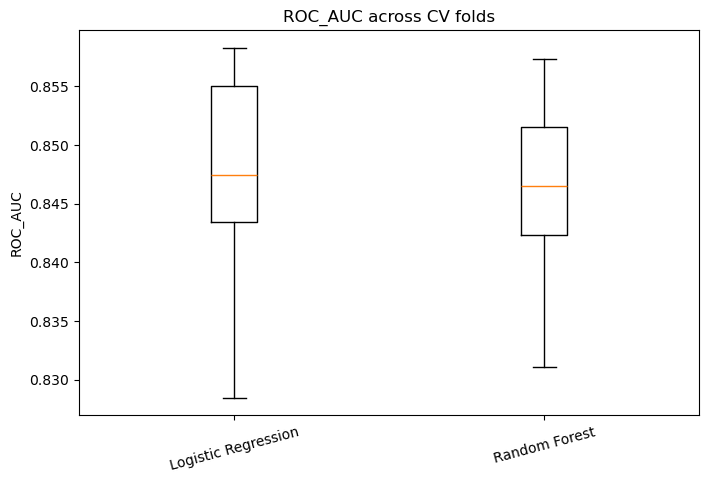

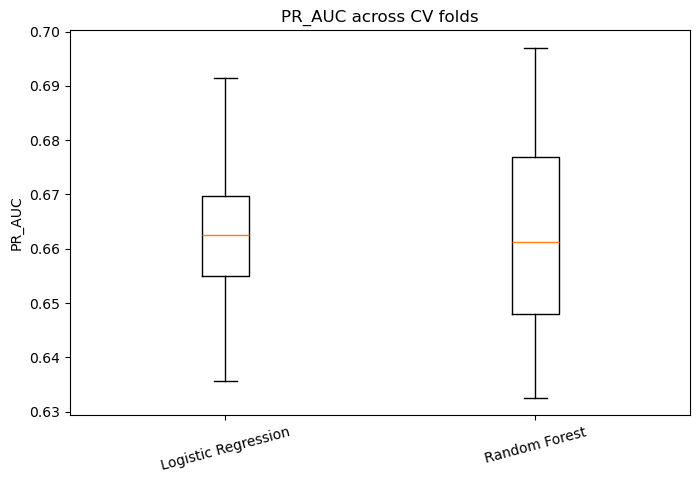

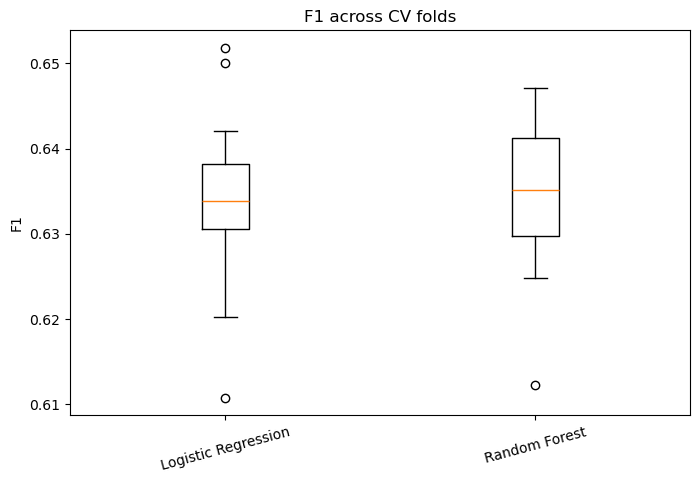

In [34]:
models_to_plot = cv_summary.loc[cv_summary["Model"] != "Dummy", "Model"].tolist()

for metric in ["roc_auc", "pr_auc", "f1"]:
    metric_df = cv_folds[
        (cv_folds["metric"] == metric) & (cv_folds["Model"] != "Dummy")
    ]

    plot_data = [
        metric_df.loc[metric_df["Model"] == model_name, "value"].values
        for model_name in models_to_plot
    ]

    plt.figure(figsize=(8, 5))
    plt.boxplot(plot_data, tick_labels=models_to_plot)
    plt.title(f"{metric.upper()} across CV folds")
    plt.ylabel(metric.upper())
    plt.xticks(rotation=15)
    plt.show()

In [35]:
ranking_columns = [
    "Model",
    "roc_auc_mean", "roc_auc_std",
    "pr_auc_mean", "pr_auc_std",
    "f1_mean", "f1_std",
    "recall_mean", "precision_mean",
    "accuracy_mean"
]

model_ranking = (
    cv_summary[ranking_columns]
    .sort_values(
        by=["roc_auc_mean", "pr_auc_mean", "f1_mean"],
        ascending=False
    )
    .reset_index(drop=True)
)

model_ranking.round(4)

,Model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,recall_mean,precision_mean,accuracy_mean
0,Logistic Regression,0.8476,0.0085,0.6624,0.0155,0.6335,0.0108,0.8054,0.5222,0.7524
1,Random Forest,0.8469,0.0070,0.6609,0.0189,0.6342,0.0094,0.7324,0.5595,0.7755
2,Dummy,0.5000,0.0000,0.2658,0.0000,0.0000,0.0000,0.0000,0.0000,0.7342


In [36]:
selected_model_name = model_ranking.loc[0, "Model"]
best_model = models[selected_model_name]

print("Selected base model:", selected_model_name)

Selected base model: Logistic Regression


## Probability-version selection on training data only

A model can rank customers well while still producing poorly calibrated probabilities.

We therefore compare three probability versions of the selected base model:

- **Uncalibrated**
- **Sigmoid calibrated**
- **Isotonic calibrated**

This selection is done using **out-of-fold training predictions only**, so the holdout set remains untouched.

In [37]:
calibration_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

calibration_candidates = {
    "Uncalibrated": best_model,
    "Sigmoid calibrated": CalibratedClassifierCV(
        estimator=best_model,
        method="sigmoid",
        cv=5
    ),
    "Isotonic calibrated": CalibratedClassifierCV(
        estimator=best_model,
        method="isotonic",
        cv=5
    )
}

train_calibration_rows = []

for name, model in calibration_candidates.items():
    y_proba_oof_cal = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=calibration_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    train_calibration_rows.append({
        "Model version": name,
        "OOF Brier score": brier_score_loss(y_train, y_proba_oof_cal),
        "OOF ROC-AUC": roc_auc_score(y_train, y_proba_oof_cal),
        "OOF PR-AUC": average_precision_score(y_train, y_proba_oof_cal)
    })

train_calibration_comparison = pd.DataFrame(train_calibration_rows)
train_calibration_comparison.round(4)

,Model version,OOF Brier score,OOF ROC-AUC,OOF PR-AUC
0,Uncalibrated,0.1642,0.8460,0.6576
1,Sigmoid calibrated,0.1352,0.8460,0.6576
2,Isotonic calibrated,0.1355,0.8453,0.6540


In [38]:
selected_probability_version = (
    train_calibration_comparison
    .sort_values(by=["OOF Brier score", "OOF ROC-AUC"], ascending=[True, False])
    .iloc[0]["Model version"]
)

print("Selected probability version:", selected_probability_version)

Selected probability version: Sigmoid calibrated


## Final probability model

After selecting the best probability version on the training data only, we fit that final probability model on the full training set.

This model will be used for:
- holdout probability evaluation,
- threshold tuning based on calibrated out-of-fold training predictions,
- and final business metrics such as gain and lift.

In [39]:
if selected_probability_version == "Uncalibrated":
    final_probability_model = best_model
elif selected_probability_version == "Sigmoid calibrated":
    final_probability_model = CalibratedClassifierCV(
        estimator=best_model,
        method="sigmoid",
        cv=5
    )
else:
    final_probability_model = CalibratedClassifierCV(
        estimator=best_model,
        method="isotonic",
        cv=5
    )

final_probability_model.fit(X_train, y_train)

final_proba_test = final_probability_model.predict_proba(X_test)[:, 1]

## Holdout probability quality

We now evaluate the final selected probability model on the untouched holdout set.

The main probability-quality metrics are:
- **Brier score**
- **reliability curve**
- and the probability distribution itself

In [40]:
final_brier = brier_score_loss(y_test, final_proba_test)
final_roc_auc = roc_auc_score(y_test, final_proba_test)
final_pr_auc = average_precision_score(y_test, final_proba_test)

print("Final holdout Brier score:", round(final_brier, 4))
print("Final holdout ROC-AUC    :", round(final_roc_auc, 4))
print("Final holdout PR-AUC     :", round(final_pr_auc, 4))

Final holdout Brier score: 0.1411
Final holdout ROC-AUC    : 0.8334
Final holdout PR-AUC     : 0.6174


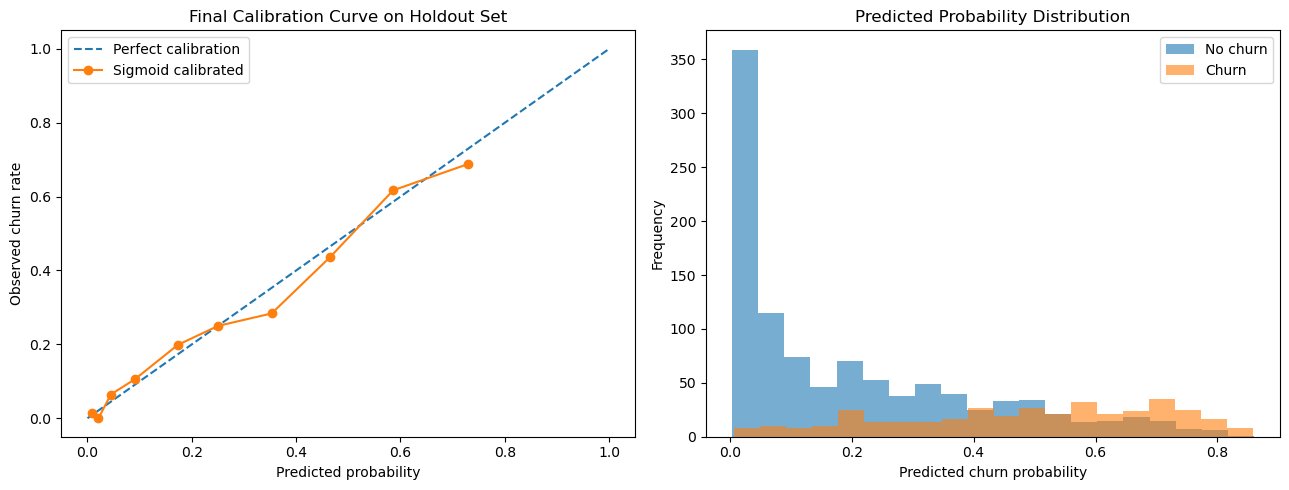

In [41]:
prob_true_final, prob_pred_final = calibration_curve(
    y_test,
    final_proba_test,
    n_bins=10,
    strategy="quantile"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration curve
axes[0].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
axes[0].plot(prob_pred_final, prob_true_final, marker="o", label=selected_probability_version)
axes[0].set_title("Final Calibration Curve on Holdout Set")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Observed churn rate")
axes[0].legend()

# Probability distribution
axes[1].hist(final_proba_test[y_test == 0], bins=20, alpha=0.6, label="No churn")
axes[1].hist(final_proba_test[y_test == 1], bins=20, alpha=0.6, label="Churn")
axes[1].set_title("Predicted Probability Distribution")
axes[1].set_xlabel("Predicted churn probability")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

## Threshold tuning on calibrated out-of-fold training probabilities

The default threshold of 0.50 is not necessarily optimal for churn prediction.

Threshold tuning should also be based on training data only. We therefore compute out-of-fold probabilities from the final selected probability model on the training set and search for a threshold that maximizes F1 among thresholds with recall of at least 0.75.

In [42]:
final_proba_oof = cross_val_predict(
    final_probability_model,
    X_train,
    y_train,
    cv=calibration_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [43]:
threshold_grid = np.linspace(0.10, 0.90, 81)

threshold_rows = []

for thr in threshold_grid:
    y_pred_thr = (final_proba_oof >= thr).astype(int)
    
    threshold_rows.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_train, y_pred_thr),
        "precision": precision_score(y_train, y_pred_thr, zero_division=0),
        "recall": recall_score(y_train, y_pred_thr, zero_division=0),
        "f1": f1_score(y_train, y_pred_thr, zero_division=0),
        "positive_rate": y_pred_thr.mean()
    })

threshold_results = pd.DataFrame(threshold_rows)

eligible = threshold_results[threshold_results["recall"] >= 0.75].copy()

if len(eligible) > 0:
    selected_threshold_row = eligible.sort_values(
        by=["f1", "precision"],
        ascending=False
    ).iloc[0]
else:
    selected_threshold_row = threshold_results.sort_values(
        by="f1",
        ascending=False
    ).iloc[0]

selected_threshold = float(selected_threshold_row["threshold"])

print("Selected threshold:", round(selected_threshold, 3))
selected_threshold_row.round(4)

Selected threshold: 0.28


threshold        0.2800
accuracy         0.7575
precision        0.5294
recall           0.7900
f1               0.6339
positive_rate    0.3966
Name: 18, dtype: float64

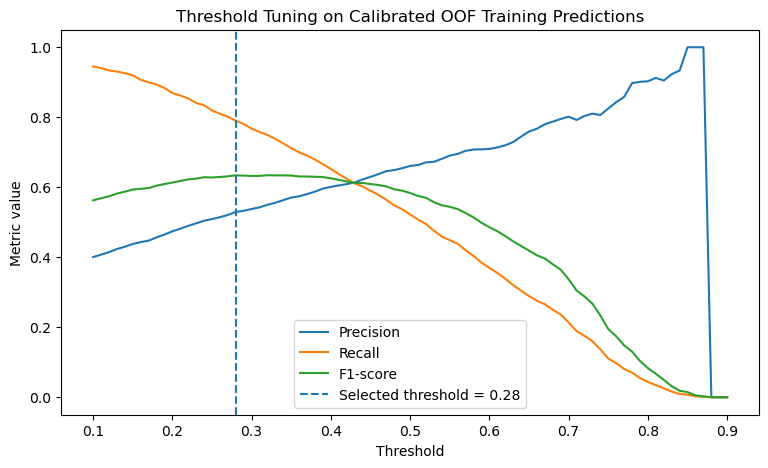

In [44]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1-score")
plt.axvline(selected_threshold, linestyle="--", label=f"Selected threshold = {selected_threshold:.2f}")
plt.title("Threshold Tuning on Calibrated OOF Training Predictions")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend()
plt.show()

## Holdout performance at default vs tuned threshold

The calibrated probabilities are now converted into class predictions on the holdout set using:
- the default threshold of 0.50,
- and the tuned threshold selected from training data only.

In [45]:
# Default threshold
y_pred_default = (final_proba_test >= 0.50).astype(int)

# Tuned threshold
y_pred_tuned = (final_proba_test >= selected_threshold).astype(int)

threshold_comparison = pd.DataFrame({
    "Setting": ["Default 0.50", f"Tuned {selected_threshold:.2f}"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_default, zero_division=0),
        precision_score(y_test, y_pred_tuned, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_default, zero_division=0),
        recall_score(y_test, y_pred_tuned, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_default, zero_division=0),
        f1_score(y_test, y_pred_tuned, zero_division=0)
    ]
})

threshold_comparison.round(4)

,Setting,Accuracy,Precision,Recall,F1-score
0,Default 0.50,0.7939,0.6364,0.5241,0.5748
1,Tuned 0.28,0.7306,0.4958,0.7807,0.6064


In [46]:
print("Confusion matrix at tuned threshold:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification report at tuned threshold:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

Confusion matrix at tuned threshold:
[[736 297]
 [ 82 292]]

Classification report at tuned threshold:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



## Bootstrap uncertainty on the holdout set

We complement cross-validation variability with bootstrap intervals on the holdout metrics.

These intervals describe uncertainty due to sampling variation in the holdout set.

In [47]:
rng = np.random.default_rng(42)
n_boot = 1000

y_test_np = np.asarray(y_test)
y_pred_tuned_np = np.asarray(y_pred_tuned)
final_proba_test_np = np.asarray(final_proba_test)

boot_rows = []

for _ in range(n_boot):
    idx = rng.integers(0, len(y_test_np), len(y_test_np))
    
    y_true_b = y_test_np[idx]
    y_pred_b = y_pred_tuned_np[idx]
    y_proba_b = final_proba_test_np[idx]
    
    if len(np.unique(y_true_b)) < 2:
        continue
    
    boot_rows.append({
        "accuracy": accuracy_score(y_true_b, y_pred_b),
        "precision": precision_score(y_true_b, y_pred_b, zero_division=0),
        "recall": recall_score(y_true_b, y_pred_b, zero_division=0),
        "f1": f1_score(y_true_b, y_pred_b, zero_division=0),
        "roc_auc": roc_auc_score(y_true_b, y_proba_b),
        "pr_auc": average_precision_score(y_true_b, y_proba_b)
    })

boot_df = pd.DataFrame(boot_rows)

boot_summary = pd.DataFrame({
    "Metric": ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
    "Median": [boot_df[m].median() for m in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]],
    "CI 2.5%": [boot_df[m].quantile(0.025) for m in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]],
    "CI 97.5%": [boot_df[m].quantile(0.975) for m in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
})

boot_summary.round(4)

,Metric,Median,CI 2.5%,CI 97.5%
0,accuracy,0.7303,0.7072,0.7520
1,precision,0.4956,0.4525,0.5341
2,recall,0.7812,0.7378,0.8217
3,f1,0.6062,0.5671,0.6390
4,roc_auc,0.8334,0.8117,0.8551
5,pr_auc,0.6200,0.5658,0.6724


## Top-k targeting performance

In practice, retention teams usually target only a fraction of the customer base.

Using the calibrated final probabilities, we measure:
- how many churners are captured in the top 10%, 20%, and 30% highest-risk customers,
- how precise those targeted groups are,
- and how much better this is than random targeting.

In [48]:
def top_k_metrics(y_true, y_score, pct):
    n = len(y_true)
    k = int(np.ceil(n * pct))
    
    eval_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_score": np.asarray(y_score)
    }).sort_values("y_score", ascending=False).reset_index(drop=True)
    
    selected = eval_df.iloc[:k]
    
    total_positives = eval_df["y_true"].sum()
    selected_positives = selected["y_true"].sum()
    
    gain = selected_positives / total_positives if total_positives > 0 else np.nan
    selected_rate = selected["y_true"].mean()
    overall_rate = eval_df["y_true"].mean()
    lift = selected_rate / overall_rate if overall_rate > 0 else np.nan
    
    return {
        "Top %": f"{int(pct * 100)}%",
        "Customers targeted": k,
        "Churners captured": int(selected_positives),
        "Recall@k": gain,
        "Precision@k": selected_rate,
        "Lift@k": lift
    }

topk_results = pd.DataFrame([
    top_k_metrics(y_test, final_proba_test, 0.10),
    top_k_metrics(y_test, final_proba_test, 0.20),
    top_k_metrics(y_test, final_proba_test, 0.30)
])

topk_results.round(4)

,Top %,Customers targeted,Churners captured,Recall@k,Precision@k,Lift@k
0,10%,141,97,0.2594,0.6879,2.5881
1,20%,282,184,0.4920,0.6525,2.4547
2,30%,423,245,0.6551,0.5792,2.1790


In [49]:
population_shares = np.arange(0.10, 1.01, 0.10)

gain_rows = []
for pct in population_shares:
    metrics_k = top_k_metrics(y_test, final_proba_test, pct)
    gain_rows.append({
        "population_share": pct,
        "gain": metrics_k["Recall@k"],
        "lift": metrics_k["Lift@k"],
        "precision_at_k": metrics_k["Precision@k"]
    })

gain_lift_df = pd.DataFrame(gain_rows)
gain_lift_df.round(4)

,population_share,gain,lift,precision_at_k
0,0.1,0.2594,2.5881,0.6879
1,0.2,0.4920,2.4547,0.6525
2,0.3,0.6551,2.1790,0.5792
3,0.4,0.7620,1.9044,0.5062
4,0.5,0.8556,1.7100,0.4545
5,0.6,0.9305,1.5493,0.4118
6,0.7,0.9706,1.3864,0.3685
7,0.8,0.9947,1.2429,0.3304
8,0.9,0.9947,1.1046,0.2936
9,1.0,1.0000,1.0000,0.2658


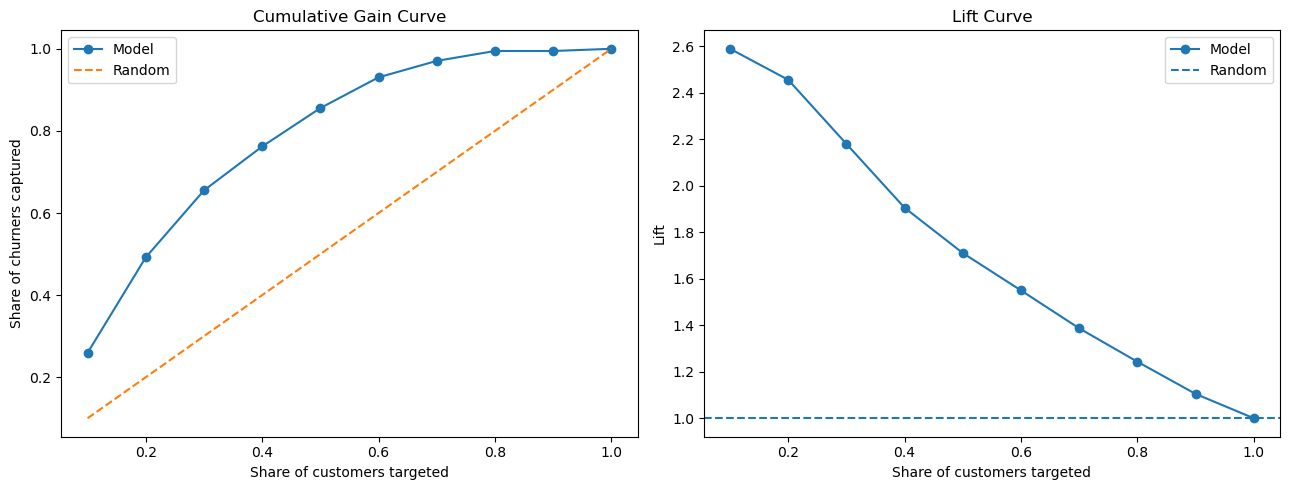

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative gain
axes[0].plot(
    gain_lift_df["population_share"],
    gain_lift_df["gain"],
    marker="o",
    label="Model"
)
axes[0].plot(
    gain_lift_df["population_share"],
    gain_lift_df["population_share"],
    linestyle="--",
    label="Random"
)
axes[0].set_title("Cumulative Gain Curve")
axes[0].set_xlabel("Share of customers targeted")
axes[0].set_ylabel("Share of churners captured")
axes[0].legend()

# Lift
axes[1].plot(
    gain_lift_df["population_share"],
    gain_lift_df["lift"],
    marker="o",
    label="Model"
)
axes[1].axhline(1.0, linestyle="--", label="Random")
axes[1].set_title("Lift Curve")
axes[1].set_xlabel("Share of customers targeted")
axes[1].set_ylabel("Lift")
axes[1].legend()

plt.tight_layout()
plt.show()